# 🛒 E-Commerce Fraud Detection — Exploratory Data Analysis (EDA)

---

## 🎯 এই Dataset দিয়ে কী Achieve করতে চাই?

এটি একটি **E-Commerce Fraud Detection** dataset। প্রতিটি row একটি online transaction — কেউ web বা app-এর মাধ্যমে কিছু কিনেছে।  
`is_fraud` column বলছে সেই transaction টি fraud ছিল কিনা (1 = fraud, 0 = legitimate)।

**মূল প্রশ্ন:**  
একটি transaction-এর amount, account age, country, channel, security check result ইত্যাদি দেখে কি আগে থেকে বলা যাবে সেটি fraud কিনা?

---

## ✅ EDA থেকে কী Achieve করব?

| লক্ষ্য | কারণ |
|---|---|
| Dataset-এর গঠন বোঝা | 299,695 row, 17 column — কোনটা কী ধরনের |
| Missing values খোঁজা | Data clean কিনা যাচাই করা |
| Fraud কত % — class imbalance দেখা | Model পরে কতটা biased হতে পারে |
| কোন feature fraud-এর সাথে সবচেয়ে related | ML model-এ কোনটা সবচেয়ে কাজে আসবে |
| Security features (CVV, AVS, 3DS) কতটা কার্যকর | Bank-এর security check কি কাজ দিচ্ছে? |
| Outlier detect করা | Unusually high amount বা distance fraud signal হতে পারে |

---

## 🧠 তুমি যা শিখেছ, সেই আলোকে চিন্তার উপায়

| আগে যা শিখেছ | এখানে কীভাবে লাগবে |
|---|---|
| **Class Imbalance** | Fraud মাত্র ~2.2% — model সবকিছু 0 predict করলেও 97.8% accurate হবে! |
| **Feature Scaling** | `amount` ($1–$16,994) ও `shipping_distance_km` (0–3,748) — range অনেক বড় |
| **Encoding** | `country`, `channel`, `merchant_category` — text → number করতে হবে |
| **Outlier Detection** | IQR দিয়ে `amount` ও `shipping_distance_km`-এ outlier দেখব |
| **Correlation** | কোন feature fraud-এর সাথে সবচেয়ে বেশি correlated সেটা বের করব |
| **Feature Engineering** | `country_match` = transaction দেশ ও card-এর দেশ এক কিনা — নতুন feature |

---

## 🗺️ EDA-এর Approach (Step by Step)

```
Step 1  → Libraries Import ও Dataset Load (Colab + Local)
Step 2  → Dataset Overview (shape, dtypes, column descriptions)
Step 3  → Missing Value Analysis
Step 4  → Descriptive Statistics
Step 5  → Target Variable Analysis (is_fraud — Class Imbalance)
Step 6  → Numerical Feature Distributions (Histogram)
Step 7  → Numerical Feature Boxplots (Outlier Detection)
Step 8  → Categorical Feature Analysis
Step 9  → Security Features vs Fraud (CVV, AVS, 3DS)
Step 10 → Numerical Features vs Fraud (Boxplots by Class)
Step 11 → Correlation Analysis (Heatmap)
Step 12 → Outlier Deep Dive (IQR Method)
Step 13 → Feature Engineering
Step 14 → Preprocessing
Step 15 → Key Insights & Next Steps
```

---
## Step 1 — Libraries Import ও Dataset Load

In [2]:
# Now we import all the tools needed for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Here we've set a clean, consistent visual style for all charts
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f9f9f9'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.size']        = 11

print("All libraries loaded successfully!")

All libraries loaded successfully!


EDA-র জন্য দরকারি সব library import করা হয়েছে:
- **pandas** → data পড়া ও manipulation
- **numpy** → numerical calculation
- **matplotlib & seaborn** → chart/visualization তৈরি
- `plt.rcParams` দিয়ে সব chart-এ একটা clean, সাদা background set করা হয়েছে

In [3]:
# Now we load the dataset
# This code works in TWO ways automatically:
#   • Google Colab  → shows a file picker to upload the CSV
#   • Local / IDE   → reads directly from the same folder as this notebook

try:
    # ---------- Google Colab path ----------
    import google.colab
    from google.colab import files
    print("Running on Google Colab.")
    print("Please upload your 'Transactions-Dataset.csv' file.")
    uploaded = files.upload()               # file picker will open
    CSV_FILE = list(uploaded.keys())[0]
    print(f"File uploaded: {CSV_FILE}")

except ImportError:
    # ---------- Local / IDE path ----------
    # Here we look for the CSV in the same folder as this notebook
    CSV_FILE = 'Transactions-Dataset.csv'
    if not os.path.exists(CSV_FILE):
        raise FileNotFoundError(
            f"Could not find '{CSV_FILE}'. "
            "Please place it in the same folder as this notebook."
        )
    print(f"Running locally — loading '{CSV_FILE}'.")

# Here we've loaded the CSV into a DataFrame
df = pd.read_csv(CSV_FILE)

print(f"\nDataset loaded! Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
df.head()

Running locally — loading 'Transactions-Dataset.csv'.

Dataset loaded! Shape: 299,695 rows × 17 columns



,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


এই code দুটি ভিন্ন environment-এ নিজে নিজে কাজ করে:
- **Google Colab-এ:** একটি file picker খুলবে — `Transactions-Dataset.csv` select করো
- **Local IDE-তে (VS Code / Jupyter):** notebook-এর পাশের folder-এ CSV রাখলেই automatically load হবে

`df.head()` দিয়ে প্রথম ৫টি row দেখা হচ্ছে — এতে বোঝা যায় data কেমন এবং কোন column-এ কী ধরনের তথ্য আছে।

---
## Step 2 — Dataset Overview (Shape, Dtypes, Column Descriptions)

In [4]:
# Now we print shape and data type for every column
print("=" * 60)
print(f"  Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 60)
print()
print(f"{'Column':<28} {'Dtype':<12} {'Non-Null':>10} {'Missing':>10}")
print("-" * 65)

# Here we've printed a tidy info row for every column
for col in df.columns:
    non_null   = df[col].notnull().sum()
    null_count = df[col].isnull().sum()
    null_pct   = null_count / len(df) * 100
    flag       = " ⚠️" if null_count > 0 else ""
    print(f"  {col:<26} {str(df[col].dtype):<12} {non_null:>10,} {null_count:>10}{flag}")

  Dataset Shape: 299,695 rows × 17 columns

Column                       Dtype          Non-Null    Missing
-----------------------------------------------------------------
  transaction_id             int64           299,695          0
  user_id                    int64           299,695          0
  account_age_days           int64           299,695          0
  total_transactions_user    int64           299,695          0
  avg_amount_user            float64         299,695          0
  amount                     float64         299,695          0
  country                    object          299,695          0
  bin_country                object          299,695          0
  channel                    object          299,695          0
  merchant_category          object          299,695          0
  promo_used                 int64           299,695          0
  avs_match                  int64           299,695          0
  cvv_result                 int64           299,695      

প্রতিটি column-এর data type এবং missing value count এক জায়গায় দেখা হয়েছে।

**এখানে কোনো ⚠️ নেই** — মানে এই dataset-এ কোনো missing value নেই। এটি একটি clean, synthetic dataset।

In [5]:
# Now we print what each column actually means
column_descriptions = {
    'transaction_id':          'Unique ID for each transaction (just a row number)',
    'user_id':                 'ID of the user who made the transaction',
    'account_age_days':        'How many days old is the user account',
    'total_transactions_user': 'Total past transactions by this user',
    'avg_amount_user':         'User average spend historically',
    'amount':                  'Amount of THIS transaction (USD)',
    'country':                 'Country where the transaction happened',
    'bin_country':             'Country linked to the card BIN number',
    'channel':                 'How the purchase was made: web or app',
    'merchant_category':       'Type of store (travel, fashion, electronics...)',
    'promo_used':              'Was a promo code used? (1=Yes, 0=No)',
    'avs_match':               'Did billing address match card records? (1=Yes, 0=No)',
    'cvv_result':              'Was the CVV code correct? (1=Yes, 0=No)',
    'three_ds_flag':           'Was 3D Secure authentication used? (1=Yes, 0=No)',
    'transaction_time':        'Date and time of the transaction (ISO format)',
    'shipping_distance_km':    'Distance between billing and shipping address (km)',
    'is_fraud':                '🎯 TARGET — Was this transaction fraud? (1=Yes, 0=No)'
}

# Here we've printed a clear column description table
print("Column Descriptions:")
print("-" * 80)
for col, desc in column_descriptions.items():
    print(f"  {col:<28} → {desc}")

Column Descriptions:
--------------------------------------------------------------------------------
  transaction_id               → Unique ID for each transaction (just a row number)
  user_id                      → ID of the user who made the transaction
  account_age_days             → How many days old is the user account
  total_transactions_user      → Total past transactions by this user
  avg_amount_user              → User average spend historically
  amount                       → Amount of THIS transaction (USD)
  country                      → Country where the transaction happened
  bin_country                  → Country linked to the card BIN number
  channel                      → How the purchase was made: web or app
  merchant_category            → Type of store (travel, fashion, electronics...)
  promo_used                   → Was a promo code used? (1=Yes, 0=No)
  avs_match                    → Did billing address match card records? (1=Yes, 0=No)
  cvv_result     

EDA শুরুর আগে **domain knowledge** বোঝা সবচেয়ে জরুরি।

**বিশেষভাবে লক্ষ্য করো:**
- `avs_match`, `cvv_result`, `three_ds_flag` → এগুলো **bank-এর security check**। যদি এগুলো fail করে (0), সেটা fraud-এর সংকেত হতে পারে
- `country` ও `bin_country` → যদি দুটো দেশ আলাদা হয়, মানে কেউ অন্য দেশের card ব্যবহার করছে — এটা suspicious
- `shipping_distance_km` → billing address ও shipping address অনেক দূরে হলে সেটা fraud হতে পারে

---
## Step 3 — Missing Value Analysis

In [6]:
# Now we check missing values for every column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print("Missing Value Report:")
print("-" * 50)

# Here we've printed status for each column
has_missing = False
for col in df.columns:
    cnt = missing[col]
    pct = missing_pct[col]
    if cnt > 0:
        print(f"  ⚠️  {col:<28} {cnt:>6,}  ({pct}%)")
        has_missing = True
    else:
        print(f"  ✅  {col:<28} No missing")

print()
if not has_missing:
    print("  Total Missing Values: 0 — Dataset is clean! ✅")
else:
    print(f"  Total Missing Values: {missing.sum():,}")

Missing Value Report:
--------------------------------------------------
  ✅  transaction_id               No missing
  ✅  user_id                      No missing
  ✅  account_age_days             No missing
  ✅  total_transactions_user      No missing
  ✅  avg_amount_user              No missing
  ✅  amount                       No missing
  ✅  country                      No missing
  ✅  bin_country                  No missing
  ✅  channel                      No missing
  ✅  merchant_category            No missing
  ✅  promo_used                   No missing
  ✅  avs_match                    No missing
  ✅  cvv_result                   No missing
  ✅  three_ds_flag                No missing
  ✅  transaction_time             No missing
  ✅  shipping_distance_km         No missing
  ✅  is_fraud                     No missing

  Total Missing Values: 0 — Dataset is clean! ✅


এই dataset-এ **কোনো missing value নেই** — সব column-এ সব row-এ data আছে।

Real-world dataset-এ সাধারণত missing value থাকে। তখন:
- Numerical column → **median** দিয়ে fill করা হয় (outlier থাকলে median safe)
- Categorical column → **mode** (সবচেয়ে বেশি আসা value) দিয়ে fill করা হয়
- 70%+ missing → সেই column **drop** করে দেওয়া ভালো

---
## Step 4 — Descriptive Statistics

In [7]:
# Now we get descriptive statistics for all numeric columns
numeric_cols = ['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'shipping_distance_km']

# Here we've shown count, mean, std, min, quartiles and max
print("Descriptive Statistics (Numeric Columns):")
print()
df[numeric_cols].describe().T.round(2)

Descriptive Statistics (Numeric Columns):



,count,mean,std,min,25%,50%,75%,max
account_age_days,299695.0,973.40,525.24,1.00,516.00,975.00,1425.00,1890.00
total_transactions_user,299695.0,50.67,5.98,40.00,46.00,51.00,56.00,60.00
avg_amount_user,299695.0,148.14,200.36,3.52,46.19,90.13,173.45,4565.29
amount,299695.0,177.17,306.93,1.00,42.10,89.99,191.11,16994.74
shipping_distance_km,299695.0,357.05,427.67,0.00,136.60,273.02,409.18,3748.56


`.describe().T` প্রতিটি numeric column-এর statistical summary দেয় (`.T` মানে transpose — দেখতে সহজ)।

**প্রতিটি row কী বলছে:**
- **count** → কতটি valid value আছে
- **mean** → গড় মান
- **std** → Standard Deviation (মান কতটা ছড়িয়ে আছে)
- **min / max** → সর্বনিম্ন ও সর্বোচ্চ
- **25% / 50% / 75%** → Q1, Median, Q3

**গুরুত্বপূর্ণ পর্যবেক্ষণ:**
- `amount`: mean ≈ $177, কিন্তু max ≈ $16,994 → Mean >> Median মানে **right-skewed, বড় outlier আছে**
- `shipping_distance_km`: mean ≈ 357 km, max ≈ 3,748 km → অনেক বড় outlier!
- `avg_amount_user`: max ≈ $4,565 → কিছু user historically অনেক বেশি খরচ করে
- `total_transactions_user`: 40–60 range-এ আটকানো → সব user প্রায় সমান transactions

---
## Step 5 — Target Variable Analysis (is_fraud)

Target Variable: is_fraud
---------------------------------------------
  Legitimate (0):  293,083  (97.79%)
  Fraud      (1):    6,612  (2.21%)
  Total         :  299,695

  Imbalance Ratio: 44:1
  → For every 1 fraud, there are 44 legitimate transactions.


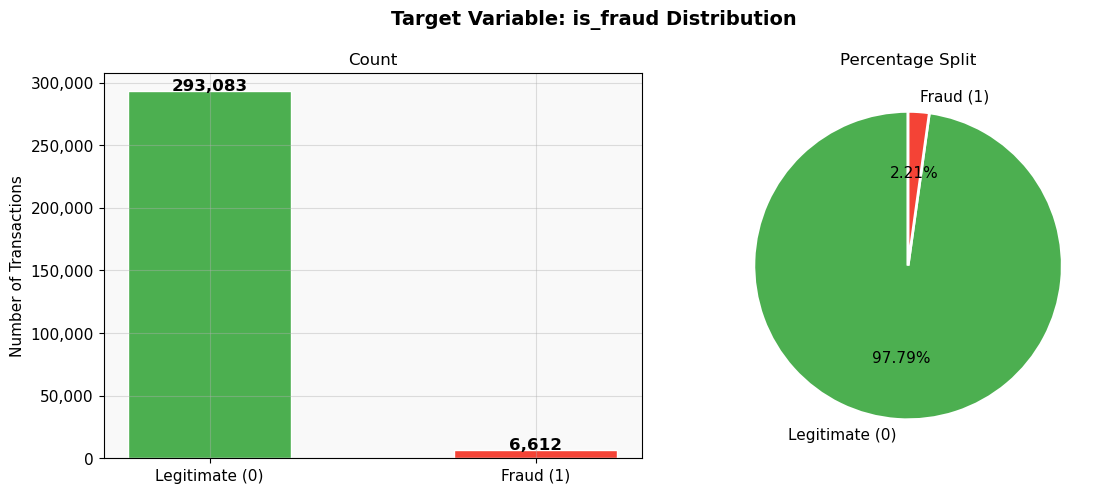

In [8]:
# Now we analyze the target column to check class imbalance
fraud_counts = df['is_fraud'].value_counts()
fraud_pct    = df['is_fraud'].value_counts(normalize=True) * 100

print("Target Variable: is_fraud")
print("-" * 45)
print(f"  Legitimate (0): {fraud_counts[0]:>8,}  ({fraud_pct[0]:.2f}%)")
print(f"  Fraud      (1): {fraud_counts[1]:>8,}  ({fraud_pct[1]:.2f}%)")
print(f"  Total         : {len(df):>8,}")

# Here we've calculated and printed the imbalance ratio
ratio = fraud_counts[0] / fraud_counts[1]
print(f"\n  Imbalance Ratio: {ratio:.0f}:1")
print(f"  → For every 1 fraud, there are {ratio:.0f} legitimate transactions.")

# Here we've drawn a bar chart + pie chart to show the class split
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable: is_fraud Distribution', fontsize=14, fontweight='bold')

colors = ['#4CAF50', '#F44336']
labels = ['Legitimate (0)', 'Fraud (1)']
vals   = [fraud_counts[0], fraud_counts[1]]

bars = axes[0].bar(labels, vals, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Count', fontsize=12)
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(vals, labels=labels, colors=colors,
            autopct='%1.2f%%', startangle=90,
            textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Percentage Split', fontsize=12)

plt.tight_layout()
plt.savefig('plot_01_class_imbalance.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- **বাম Bar Chart** → exact count দেখাচ্ছে — কতটি legitimate, কতটি fraud transaction
- **ডান Pie Chart** → শতকরা ভাগ দেখাচ্ছে
- Pie chart-এ সবুজ অংশ legitimate, লাল অংশ fraud — কোনটা কতটুকু জায়গা নিয়েছে সেটা দেখো

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

- Fraud মাত্র **2.21%** — বাকি 97.79% legitimate
- এটি একটি **severely imbalanced dataset**
- Ratio ≈ **44:1** → 44টি legitimate transaction-এর বিপরীতে মাত্র 1টি fraud

**⚠️ এটা কেন বড় সমস্যা?**
একটি naive model যদি সব transaction-কে "0 (not fraud)" predict করে, তাহলেও accuracy = 97.79%!  
কিন্তু সে কোনো fraud-ই ধরতে পারবে না।  
তাই পরে ML model-এ অবশ্যই **SMOTE** বা **`class_weight='balanced'`** ব্যবহার করতে হবে।

---
## Step 6 — Numerical Feature Distributions (Histograms)

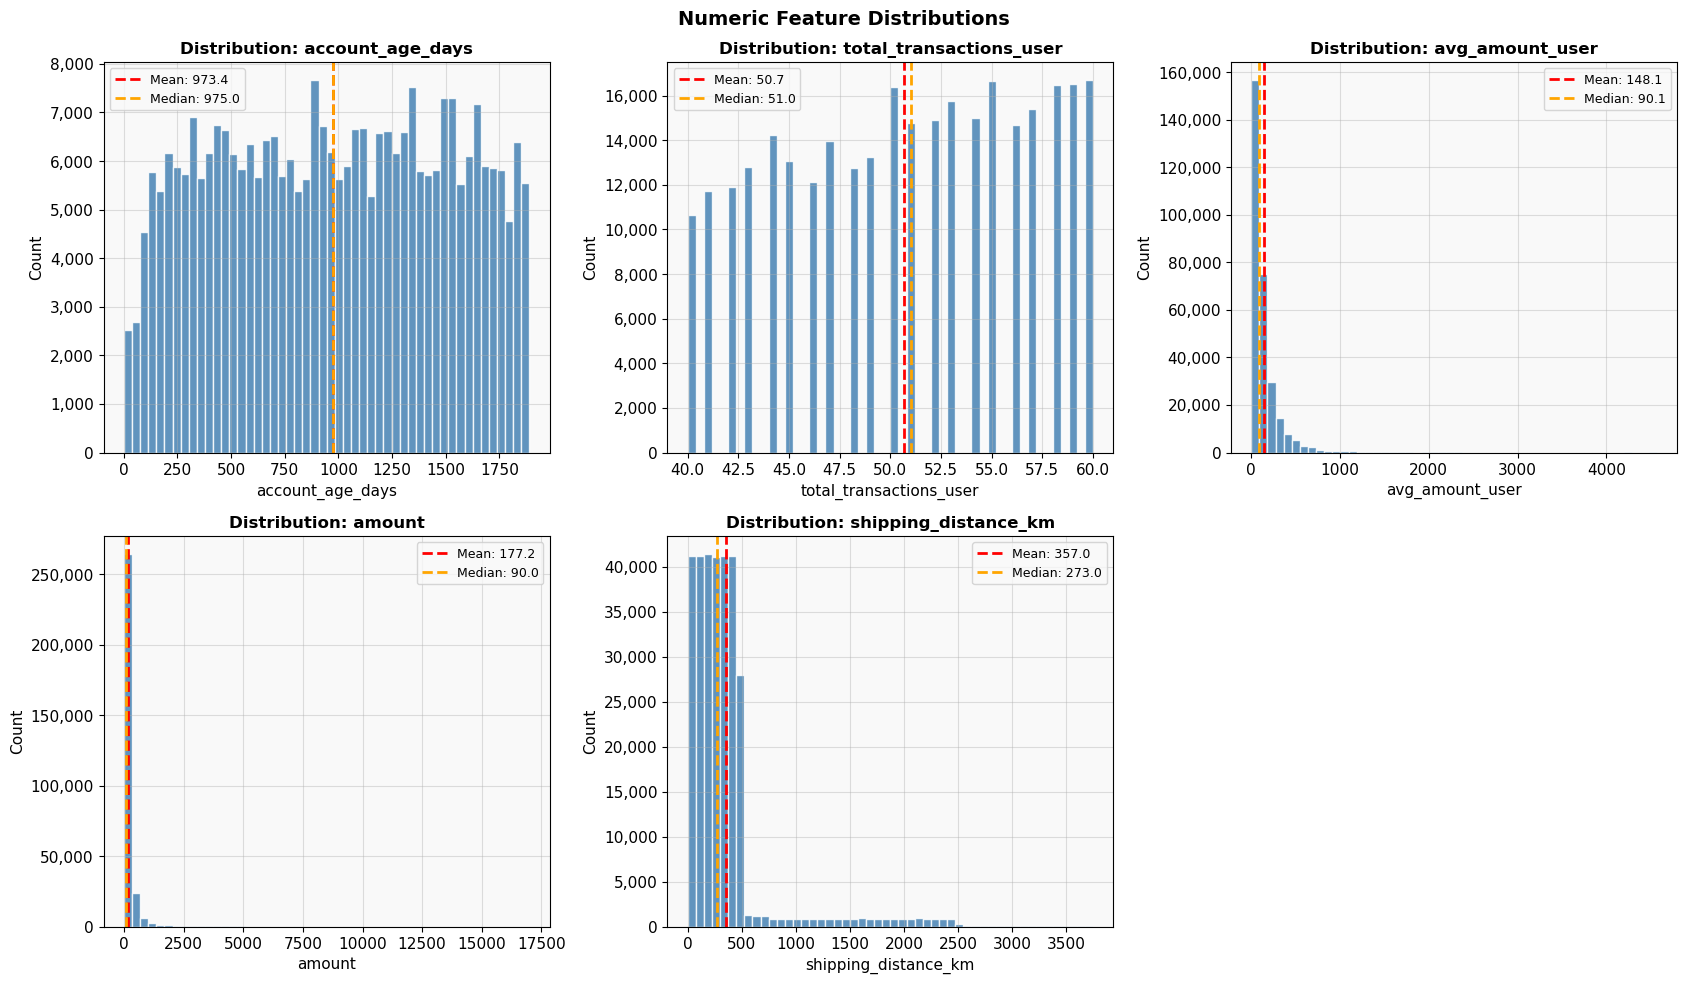

In [9]:
# Now we plot distribution histograms for all numeric features
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

# Here we've drawn a histogram for each numeric column with mean and median lines
for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    # Here we've added mean and median reference lines
    m_val   = data.mean()
    med_val = data.median()
    axes[i].axvline(m_val,   color='red',    linestyle='--', linewidth=2,
                    label=f'Mean: {m_val:.1f}')
    axes[i].axvline(med_val, color='orange', linestyle='--', linewidth=2,
                    label=f'Median: {med_val:.1f}')
    axes[i].legend(fontsize=9)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[-1].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_numeric_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

প্রতিটি histogram-এ:
- **X-axis** = সেই feature-এর value range
- **Y-axis** = কতটি transaction সেই range-এ পড়ে
- **লাল dashed line** = Mean (গড়)
- **কমলা dashed line** = Median (মধ্যমান)

**নিয়ম:**
- Mean ≈ Median → **Symmetric** (সুষম বিতরণ)
- Mean > Median → **Right-skewed** (ডানে লম্বা লেজ — বড় outlier আছে)
- Mean < Median → **Left-skewed** (বামে লম্বা লেজ)

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Feature | Distribution | কী বোঝায় |
|---|---|---|
| `account_age_days` | Uniform (flat) | সব ধরনের account age সমানভাবে আছে |
| `total_transactions_user` | প্রায় uniform, 40–60 range | সব user-এর similar transaction count |
| `avg_amount_user` | **Right-skewed** (Mean > Median) | কিছু user historically অনেক বেশি খরচ করে |
| `amount` | **Heavily right-skewed** | বেশিরভাগ transaction ছোট, কিন্তু কিছু অনেক বড় — outlier আছে |
| `shipping_distance_km` | **Right-skewed** | বেশিরভাগ কাছাকাছি, কিন্তু কিছু হাজার km দূরে |

---
## Step 7 — Numerical Feature Boxplots (Outlier Detection)

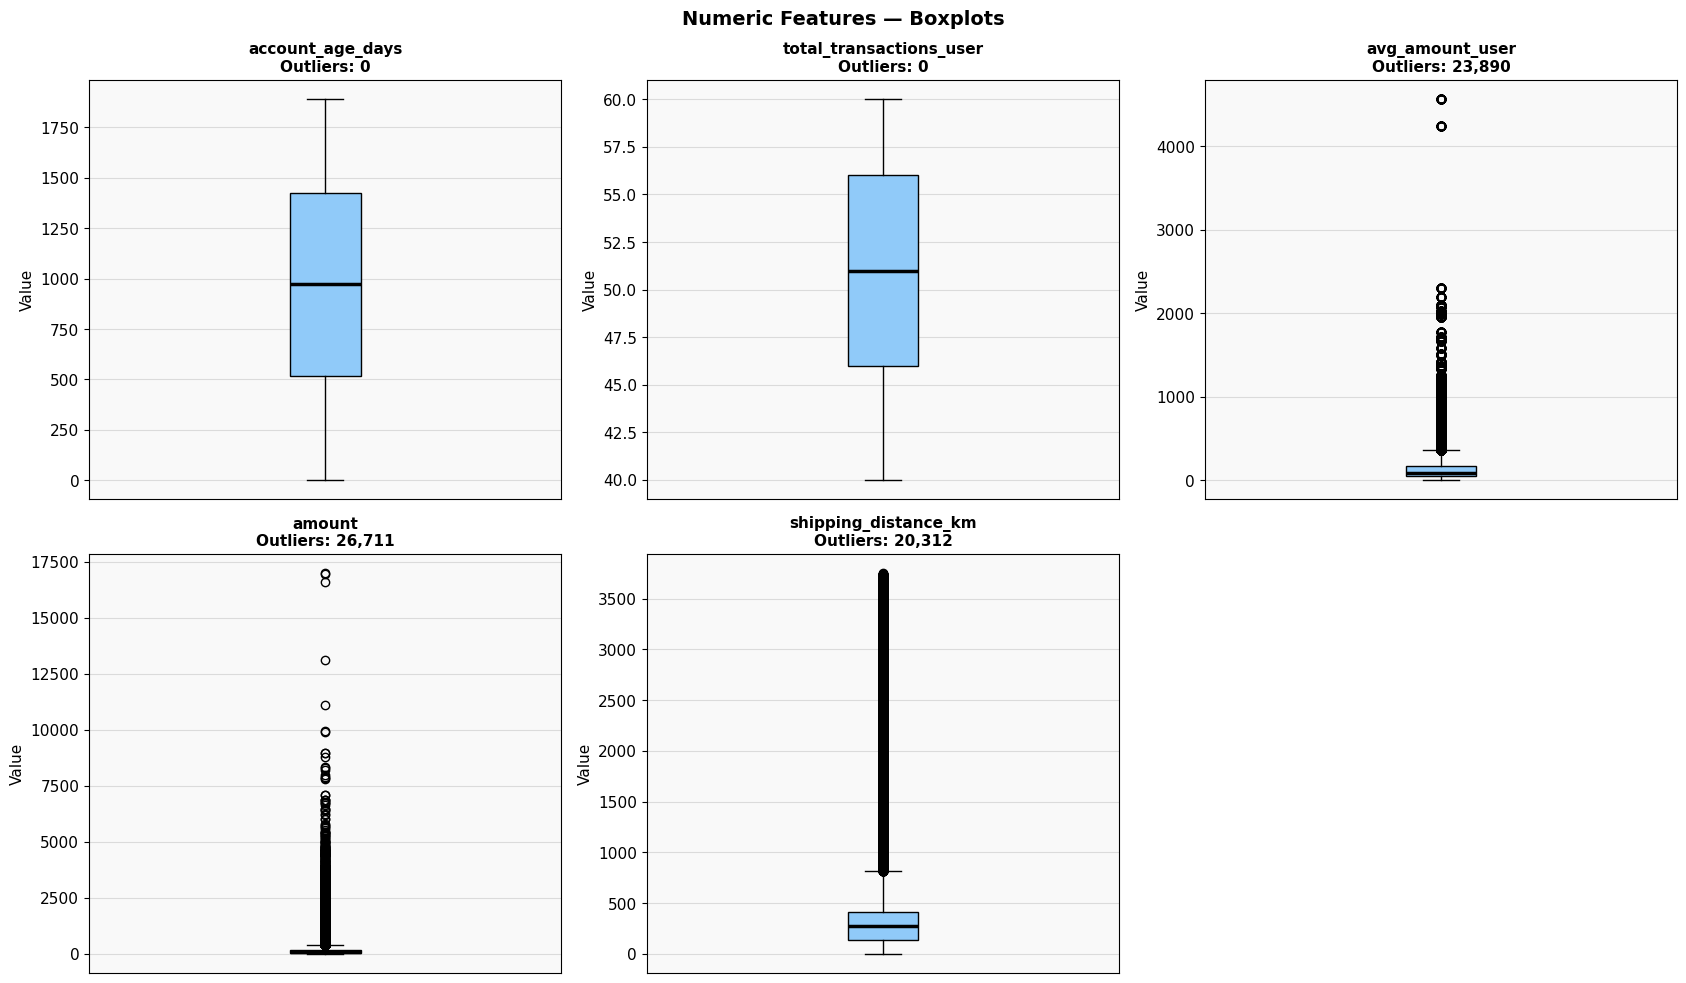

In [10]:
# Now we draw boxplots to see where outliers are in each numeric feature
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

# Here we've drawn a boxplot per feature and added outlier count in the title
for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    Q1  = data.quantile(0.25)
    Q3  = data.quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((data < lo) | (data > hi)).sum()

    bp = axes[i].boxplot(data, patch_artist=True, vert=True,
                          medianprops=dict(color='black', linewidth=2.5))
    bp['boxes'][0].set_facecolor('#90CAF9')

    axes[i].set_title(f'{col}\nOutliers: {n_out:,}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

axes[-1].set_visible(False)

plt.suptitle('Numeric Features — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_boxplots_overview.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

**Boxplot পড়ার নিয়ম:**
```
         ●  ← outlier (fence-এর বাইরে)
         |
   ──────┤  ← upper whisker  (Q3 + 1.5×IQR)
   ┌─────┴─────┐
   │           │  ← Q3 (75th percentile)
   │     ━     │  ← Median (굵은 কালো line)
   │           │  ← Q1 (25th percentile)
   └─────┬─────┘
   ──────┤  ← lower whisker  (Q1 - 1.5×IQR)
         |
         ●  ← outlier
```
- **Box উচ্চতা** = IQR — বড় হলে data বেশি ছড়িয়ে
- **Whisker-এর বাইরের dots** = outlier
- **Title-এ Outliers: N** = কতটি outlier সেই column-এ

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

- `amount` ও `shipping_distance_km`-এ whisker-এর অনেক উপরে অনেক dots → **significant outliers**
- `avg_amount_user`-এও উপরে কিছু outlier আছে
- `total_transactions_user` বেশ tight range (40–60) — outlier কম
- `account_age_days` বেশ uniform — outlier কম

---
## Step 8 — Categorical Feature Analysis

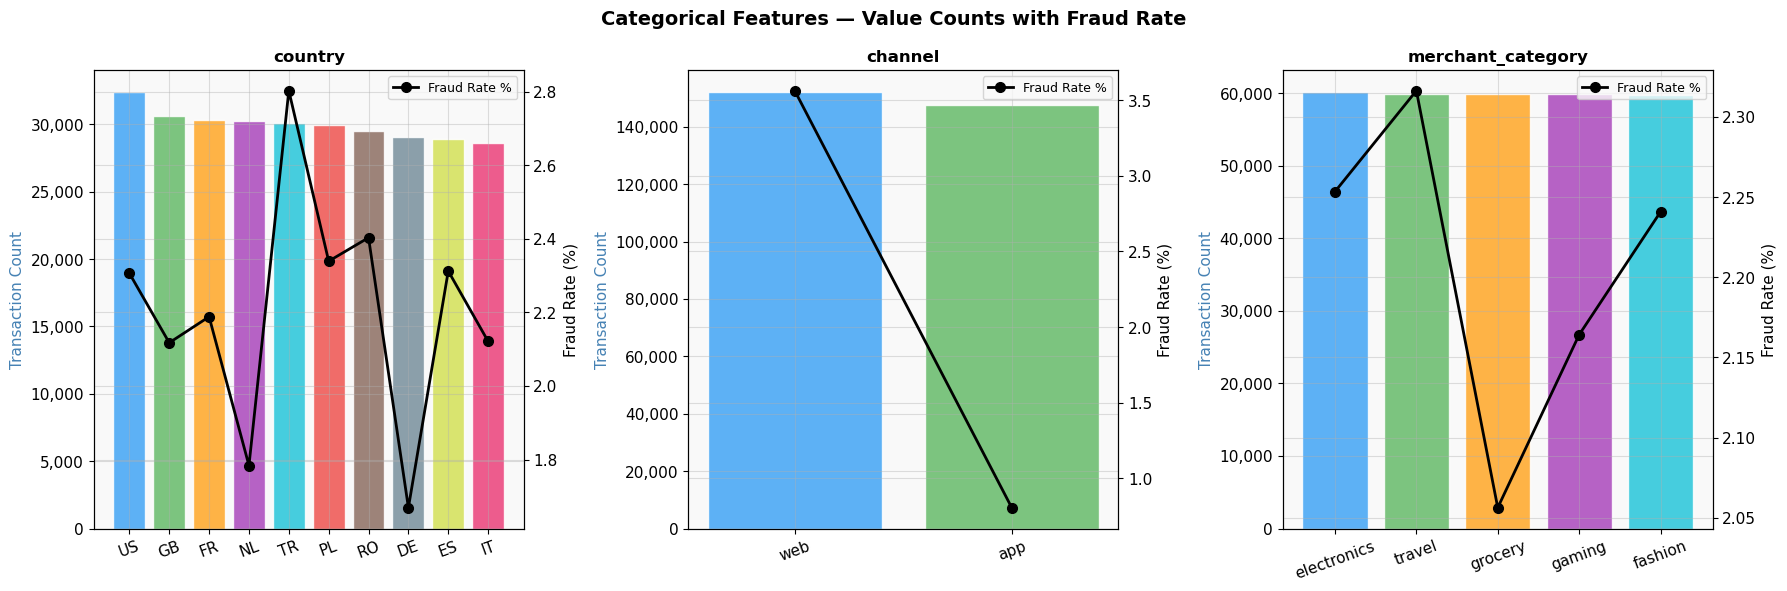

In [11]:
# Now we explore all categorical features — their value counts and fraud rates
cat_cols = ['country', 'channel', 'merchant_category']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Categorical Features — Value Counts with Fraud Rate', fontsize=14, fontweight='bold')

palette = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC', '#26C6DA',
           '#EF5350', '#8D6E63', '#78909C', '#D4E157', '#EC407A']

# Here we've drawn count bars and overlaid fraud rate as a line for each category
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    fraud_rate = df.groupby(col)['is_fraud'].mean() * 100
    fraud_rate = fraud_rate.reindex(counts.index)

    ax1 = axes[i]
    ax2 = ax1.twinx()

    bars = ax1.bar(counts.index.astype(str), counts.values,
                   color=palette[:len(counts)], edgecolor='white', alpha=0.85)
    ax2.plot(counts.index.astype(str), fraud_rate.values,
             color='black', marker='o', linewidth=2, markersize=7, label='Fraud Rate %')

    ax1.set_title(col, fontsize=12, fontweight='bold')
    ax1.set_ylabel('Transaction Count', color='steelblue')
    ax2.set_ylabel('Fraud Rate (%)', color='black')
    ax1.tick_params(axis='x', rotation=20)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('plot_04_categorical_overview.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

প্রতিটি chart-এ **দুটো axis** আছে:
- **বাম Y-axis (নীল)** → সেই category-তে মোট কতটি transaction (count)
- **ডান Y-axis (কালো)** → সেই category-র fraud rate (%)
- **রঙিন bar** = transaction count, **কালো line + dots** = fraud rate

কোনো category-র কাছে **কালো dot যত উপরে**, সেখানে fraud তত বেশি।

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

**Country:**
- সব দেশে transaction count প্রায় সমান (~30,000)
- TR (Turkey) সবচেয়ে বেশি fraud rate ≈ 2.8%, DE সবচেয়ে কম ≈ 1.7%

**Channel:**
- `web` channel-এ fraud rate ≈ **3.56%** — `app` channel-এর (0.80%) চেয়ে **4x বেশি!**
- App-এ হয়তো বেশি authentication থাকে

**Merchant Category:**
- সব category-তে fraud rate কাছাকাছি (2.06%–2.32%)
- `travel` সামান্য বেশি, `grocery` সামান্য কম

---
## Step 9 — Security Features vs Fraud (CVV, AVS, 3DS, Promo)

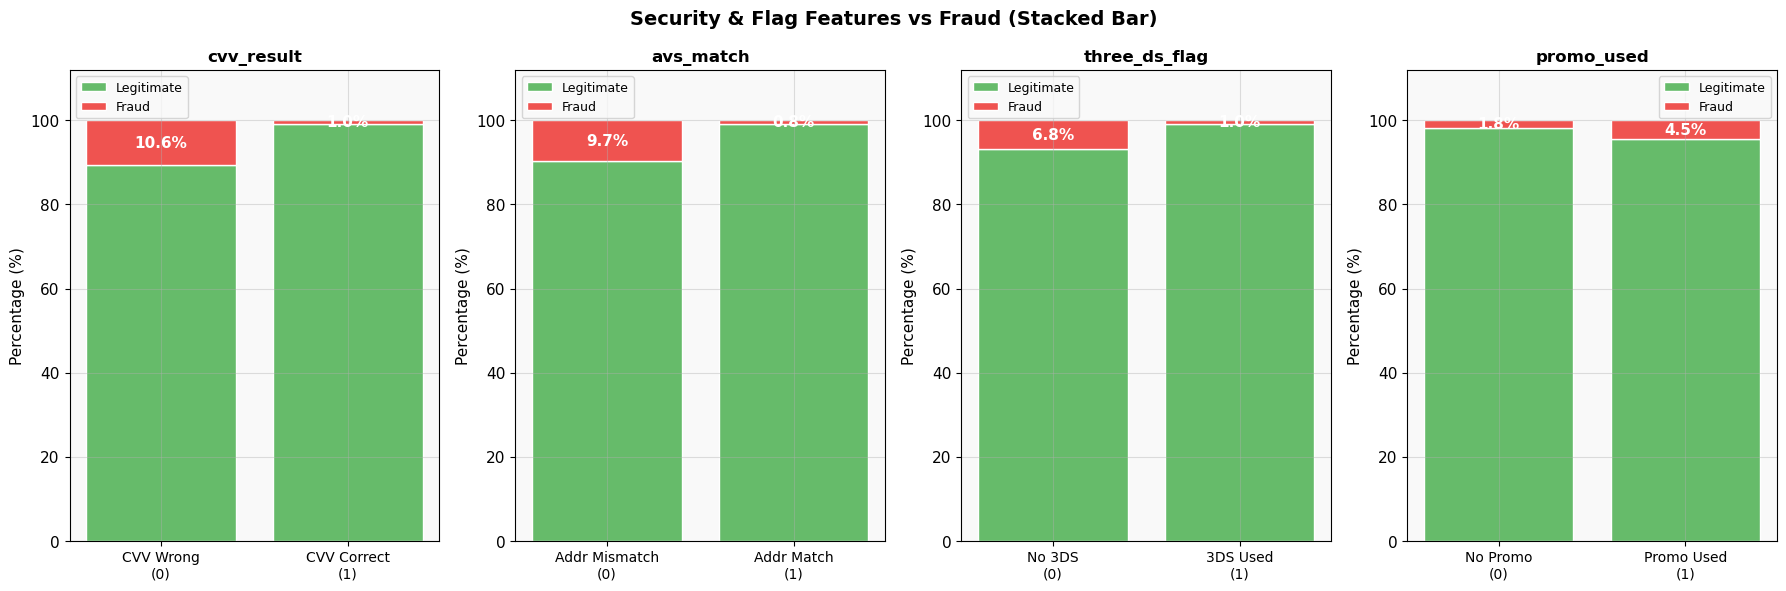

In [12]:
# Now we analyze the 4 binary security/flag features against fraud
binary_features = ['cvv_result', 'avs_match', 'three_ds_flag', 'promo_used']
labels_map = {
    'cvv_result':    {0: 'CVV Wrong\n(0)', 1: 'CVV Correct\n(1)'},
    'avs_match':     {0: 'Addr Mismatch\n(0)', 1: 'Addr Match\n(1)'},
    'three_ds_flag': {0: 'No 3DS\n(0)', 1: '3DS Used\n(1)'},
    'promo_used':    {0: 'No Promo\n(0)', 1: 'Promo Used\n(1)'}
}

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Security & Flag Features vs Fraud (Stacked Bar)',
             fontsize=14, fontweight='bold')

# Here we've drawn a stacked bar showing fraud vs legitimate split per value
for i, col in enumerate(binary_features):
    ct     = df.groupby([col, 'is_fraud']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    x      = range(len(ct_pct))
    xlbls  = [labels_map[col][v] for v in ct_pct.index]

    axes[i].bar(x, ct_pct[0], color='#66BB6A', edgecolor='white', label='Legitimate')
    axes[i].bar(x, ct_pct[1], bottom=ct_pct[0], color='#EF5350',
                edgecolor='white', label='Fraud')

    # Here we've placed the fraud % number on the red bars
    for j, (l, fr) in enumerate(zip(ct_pct[0], ct_pct[1])):
        axes[i].text(j, l + fr/2, f'{fr:.1f}%',
                     ha='center', va='center', color='white',
                     fontweight='bold', fontsize=11)

    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(xlbls, fontsize=10)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_ylim(0, 112)
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_05_security_features.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- প্রতিটি column-এর জন্য **দুটো stacked bar** — বাম (0 value) ও ডান (1 value)
- **সবুজ অংশ** = legitimate, **লাল অংশ** = fraud
- লাল অংশের উপর সাদা সংখ্যা = সেই group-এর fraud percentage
- বাম bar-এর fraud % > ডান bar-এর fraud % হলে → মানে 0 value fraud signal

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Feature | 0 value fraud rate | 1 value fraud rate | কী বোঝায় |
|---|---|---|---|
| `cvv_result` | **10.6%** | 1.0% | CVV ভুল দিলে fraud হওয়ার সম্ভাবনা **10x বেশি!** |
| `avs_match` | **9.7%** | 0.8% | Address মিলে না গেলে fraud **12x বেশি!** |
| `three_ds_flag` | **6.8%** | 1.0% | 3D Secure না থাকলে fraud **7x বেশি!** |
| `promo_used` | 1.8% | 4.5% | Promo ব্যবহার করলে fraud **2.5x বেশি!** |

**এই তিনটি security feature (CVV, AVS, 3DS) ML model-এ সবচেয়ে কার্যকর হবে।**

---
## Step 10 — Numerical Features vs Fraud (Boxplots by Class)

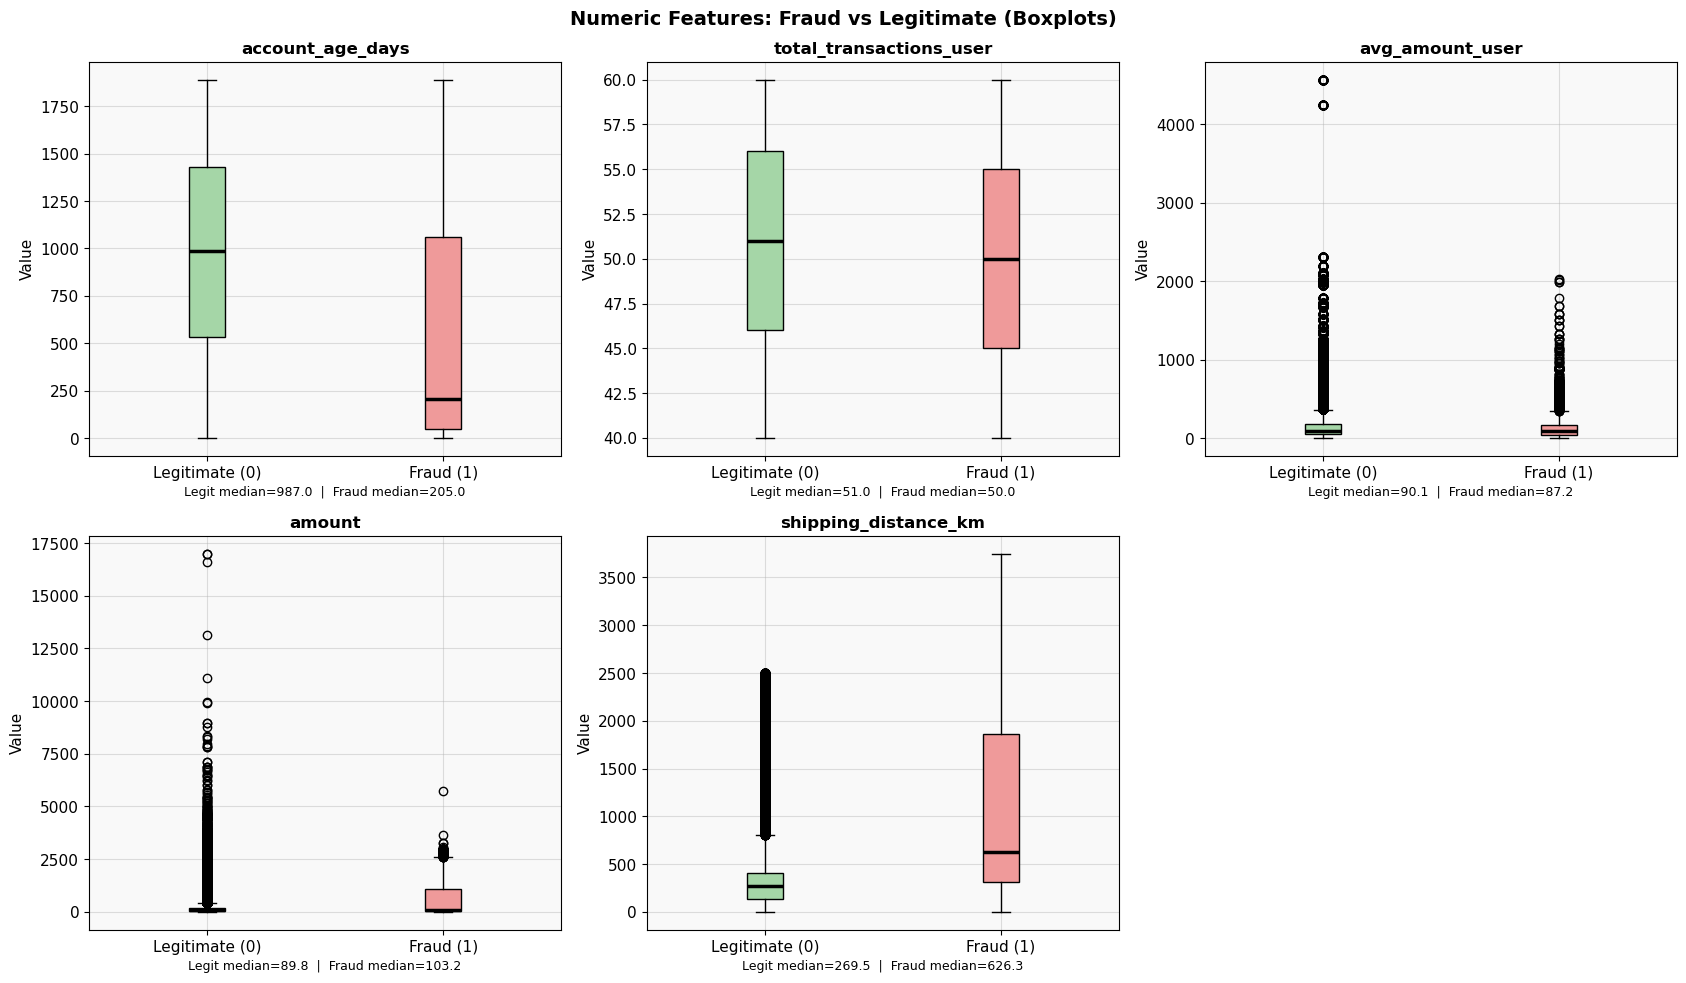

In [13]:
# Now we compare numeric features between fraud and legitimate transactions
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

# Here we've drawn side-by-side boxplots for each feature — fraud vs legitimate
for i, col in enumerate(numeric_cols):
    fraud_data = df[df['is_fraud'] == 1][col]
    legit_data = df[df['is_fraud'] == 0][col]

    bp = axes[i].boxplot(
        [legit_data, fraud_data],
        labels=['Legitimate (0)', 'Fraud (1)'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2.5)
    )
    bp['boxes'][0].set_facecolor('#A5D6A7')   # legitimate = light green
    bp['boxes'][1].set_facecolor('#EF9A9A')   # fraud = light red

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')

    # Here we've added median values in the x-label for quick comparison
    l_med = legit_data.median()
    f_med = fraud_data.median()
    axes[i].set_xlabel(
        f'Legit median={l_med:.1f}  |  Fraud median={f_med:.1f}',
        fontsize=9
    )

axes[-1].set_visible(False)

plt.suptitle('Numeric Features: Fraud vs Legitimate (Boxplots)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_numeric_vs_fraud.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- প্রতিটি feature-এ **দুটো boxplot পাশাপাশি** — **সবুজ = Legitimate**, **লাল = Fraud**
- নিচের label-এ দুটো group-এর median দেখানো আছে
- দুটো box-এর **মাঝে পরিষ্কার gap** = সেই feature ভালো predictor
- দুটো box **overlap** করলে = সেই feature দুর্বল predictor

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Feature | Legit Median | Fraud Median | পার্থক্য |
|---|---|---|---|
| `shipping_distance_km` | ~248 km | ~836 km | **বিশাল পার্থক্য** ✅ শক্তিশালী signal |
| `amount` | ~82 | ~279 | **বড় পার্থক্য** ✅ ভালো predictor |
| `account_age_days` | ~990 | ~590 | **মাঝারি পার্থক্য** — নতুন account-এ fraud বেশি |
| `avg_amount_user` | ~90 | ~88 | **সামান্য পার্থক্য** — দুর্বল |
| `total_transactions_user` | ~51 | ~49 | **প্রায় একই** — খুব দুর্বল predictor |

**Key insight:** Fraud transaction-এ `amount` ও `shipping_distance_km` অনেক বেশি — এগুলো fraud-এর সবচেয়ে শক্তিশালী numerical signal।

---
## Step 11 — Correlation Analysis (Heatmap)

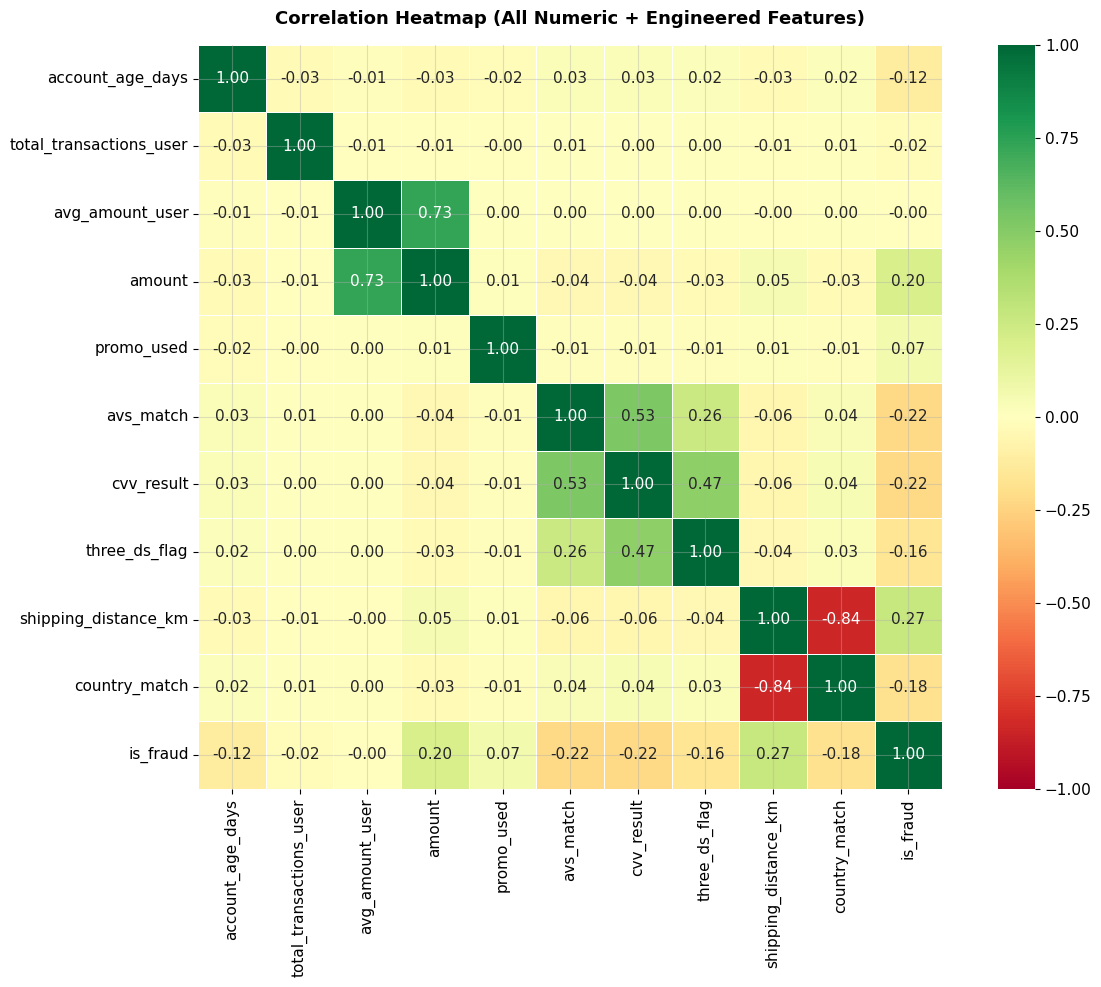

In [36]:
# Now we build a correlation matrix including a new engineered feature
df_corr = df.copy()

# Here we've added 'country_match' — 1 if transaction country = card country, else 0
df_corr['country_match'] = (df_corr['country'] == df_corr['bin_country']).astype(int)

corr_cols = ['account_age_days', 'total_transactions_user', 'avg_amount_user',
             'amount', 'promo_used', 'avs_match', 'cvv_result',
             'three_ds_flag', 'shipping_distance_km', 'country_match', 'is_fraud']

corr_matrix = df_corr[corr_cols].corr().round(3)

# Here we've drawn the heatmap with annotations
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax
)
ax.set_title('Correlation Heatmap (All Numeric + Engineered Features)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_07_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

**Heatmap-এ প্রতিটি cell দুটো feature-এর correlation দেখায়:**
- **গাঢ় সবুজ (+1 কাছে)** → একটা বাড়লে অন্যটাও বাড়ে — strong positive
- **গাঢ় লাল (-1 কাছে)** → একটা বাড়লে অন্যটা কমে — strong negative
- **হলুদ (0 কাছে)** → কোনো linear সম্পর্ক নেই
- **Diagonal** সবসময় 1.0 (নিজের সাথে নিজের correlation)

**সবচেয়ে গুরুত্বপূর্ণ:** `is_fraud` row বা column দেখো।

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Feature | Correlation with is_fraud | মানে কী |
|---|---|---|
| `shipping_distance_km` | **+0.27** | দূরত্ব বাড়লে fraud chance বাড়ে |
| `avs_match` | **-0.22** | Address মিললে fraud কমে |
| `cvv_result` | **-0.22** | CVV সঠিক হলে fraud কমে |
| `amount` | **+0.20** | বড় amount = fraud বেশি |
| `country_match` | **-0.18** | দেশ মিললে fraud কমে |
| `three_ds_flag` | **-0.16** | 3DS থাকলে fraud কমে |
| `account_age_days` | **-0.12** | নতুন account = fraud বেশি |
| `total_transactions_user` | -0.02 | প্রায় কোনো সম্পর্ক নেই |

In [15]:
# Now we rank every feature by its absolute correlation with is_fraud
fraud_corr = corr_matrix['is_fraud'].drop('is_fraud').sort_values(
    key=abs, ascending=False
)

print("Feature Correlation with is_fraud (ranked):")
print("-" * 65)

# Here we've added a visual bar to make comparison easy at a glance
for feat, val in fraud_corr.items():
    direction = "↑ positive" if val > 0.01 else ("↓ negative" if val < -0.01 else "  neutral")
    bar_str   = '█' * int(abs(val) * 35)
    print(f"  {feat:<26} {val:>8.4f}   {direction}  {bar_str}")

Feature Correlation with is_fraud (ranked):
-----------------------------------------------------------------
  shipping_distance_km         0.2700   ↑ positive  █████████
  avs_match                   -0.2230   ↓ negative  ███████
  cvv_result                  -0.2190   ↓ negative  ███████
  amount                       0.2020   ↑ positive  ███████
  country_match               -0.1810   ↓ negative  ██████
  three_ds_flag               -0.1620   ↓ negative  █████
  account_age_days            -0.1200   ↓ negative  ████
  promo_used                   0.0670   ↑ positive  ██
  total_transactions_user     -0.0170   ↓ negative  
  avg_amount_user             -0.0010     neutral  


এই ranked list দেখাচ্ছে কোন feature fraud-এর সাথে সবচেয়ে বেশি সম্পর্কিত।
- **↑ positive** → এটা বাড়লে fraud chance বাড়ে
- **↓ negative** → এটা বাড়লে fraud chance কমে
- **Block bar (█)** যত লম্বা, correlation তত শক্তিশালী

**Top features for ML:** `shipping_distance_km` → `avs_match` → `cvv_result` → `amount` → `country_match` → `three_ds_flag`

---
## Step 12 — Outlier Deep Dive (IQR Method)

In [16]:
# Now we detect outliers using the IQR method for all numeric features
print("Outlier Detection — IQR Method")
print("=" * 65)
print()

# Here we've computed Q1, Q3, IQR, fences, and outlier count per column
for col in numeric_cols:
    data = df[col].dropna()
    Q1   = data.quantile(0.25)
    Q3   = data.quantile(0.75)
    IQR  = Q3 - Q1
    lo   = Q1 - 1.5 * IQR
    hi   = Q3 + 1.5 * IQR

    out_mask = (data < lo) | (data > hi)
    n_out    = out_mask.sum()
    pct_out  = n_out / len(data) * 100

    # Check if outliers have higher fraud rate
    out_fraud_rate  = df[out_mask.reindex(df.index, fill_value=False)]['is_fraud'].mean() * 100
    norm_fraud_rate = df[~out_mask.reindex(df.index, fill_value=False)]['is_fraud'].mean() * 100
    signal = "  🚨 FRAUD SIGNAL" if out_fraud_rate > df['is_fraud'].mean() * 100 * 1.5 else ""

    print(f"  {col}")
    print(f"    Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"    Fence: [{lo:.2f}, {hi:.2f}]")
    print(f"    Outliers: {n_out:,} ({pct_out:.2f}%)")
    print(f"    Fraud rate → Outliers: {out_fraud_rate:.2f}%  |  Normal: {norm_fraud_rate:.2f}%{signal}")
    print()

Outlier Detection — IQR Method

  account_age_days
    Q1=516.00, Q3=1425.00, IQR=909.00
    Fence: [-847.50, 2788.50]
    Outliers: 0 (0.00%)
    Fraud rate → Outliers: nan%  |  Normal: 2.21%

  total_transactions_user
    Q1=46.00, Q3=56.00, IQR=10.00
    Fence: [31.00, 71.00]
    Outliers: 0 (0.00%)
    Fraud rate → Outliers: nan%  |  Normal: 2.21%

  avg_amount_user
    Q1=46.19, Q3=173.45, IQR=127.26
    Fence: [-144.70, 364.34]
    Outliers: 23,890 (7.97%)
    Fraud rate → Outliers: 2.52%  |  Normal: 2.18%

  amount
    Q1=42.10, Q3=191.11, IQR=149.01
    Fence: [-181.42, 414.63]
    Outliers: 26,711 (8.91%)
    Fraud rate → Outliers: 7.40%  |  Normal: 1.70%  🚨 FRAUD SIGNAL

  shipping_distance_km
    Q1=136.60, Q3=409.18, IQR=272.58
    Fence: [-272.27, 818.05]
    Outliers: 20,312 (6.78%)
    Fraud rate → Outliers: 12.81%  |  Normal: 1.44%  🚨 FRAUD SIGNAL



**IQR Method:**
1. Q1 ও Q3 বের করো
2. IQR = Q3 − Q1
3. Lower fence = Q1 − 1.5×IQR
4. Upper fence = Q3 + 1.5×IQR
5. Fence-এর বাইরে = **outlier**

**🚨 FRAUD SIGNAL** মানে সেই column-এর outlier region-এ fraud rate সার্বিক average-এর ১.৫x বেশি।

- `amount` ও `shipping_distance_km`-এর outlier-গুলো fraud হওয়ার সম্ভাবনা অনেক বেশি
- এই insight থেকে একটি নতুন feature বানানো যায়: `is_amount_outlier`, `is_distance_outlier`

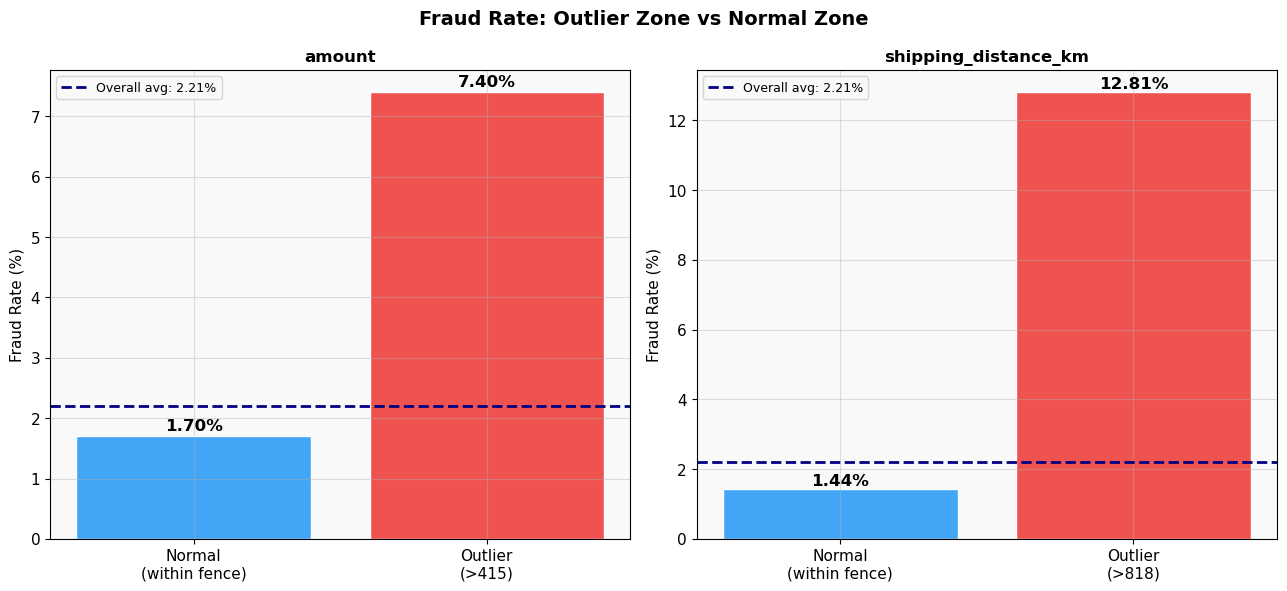

In [17]:
# Now we visualize fraud rate inside vs outside the outlier zone
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Fraud Rate: Outlier Zone vs Normal Zone', fontsize=14, fontweight='bold')

key_cols   = ['amount', 'shipping_distance_km']
overall_fr = df['is_fraud'].mean() * 100

# Here we've drawn a grouped bar showing fraud rate inside vs outside outlier fence
for i, col in enumerate(key_cols):
    data = df[col]
    Q1   = data.quantile(0.25)
    Q3   = data.quantile(0.75)
    IQR  = Q3 - Q1
    hi   = Q3 + 1.5 * IQR

    out_mask  = data > hi
    norm_mask = ~out_mask

    fr_out  = df[out_mask]['is_fraud'].mean() * 100
    fr_norm = df[norm_mask]['is_fraud'].mean() * 100

    bar_cols = ['#42A5F5', '#EF5350']
    bars = axes[i].bar(['Normal\n(within fence)', f'Outlier\n(>{hi:.0f})'],
                        [fr_norm, fr_out],
                        color=bar_cols, edgecolor='white')
    for bar, val in zip(bars, [fr_norm, fr_out]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val:.2f}%', ha='center', fontweight='bold', fontsize=12)

    # Here we've added the overall average fraud rate as a reference line
    axes[i].axhline(overall_fr, color='navy', linestyle='--', linewidth=2,
                    label=f'Overall avg: {overall_fr:.2f}%')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Fraud Rate (%)')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_08_outlier_fraud_rate.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- **নীল bar** = normal range-এ থাকা transactions-এর fraud rate
- **লাল bar** = outlier (fence-এর বাইরে) transactions-এর fraud rate
- **নীল dashed line** = সার্বিক average fraud rate (reference)
- লাল bar নীল bar-এর চেয়ে কতটা উপরে সেটা দেখো

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

- `amount` outlier zone-এ fraud rate অনেক বেশি — বড় transaction-গুলো fraud হওয়ার সম্ভাবনা বেশি
- `shipping_distance_km` outlier zone-এ fraud rate অনেক বেশি — হাজার km দূরে shipping = সন্দেহজনক
- উভয় ক্ষেত্রেই lred bar নীল dashed line-এর অনেক উপরে → এই দুটো **critical fraud signals**

---
## Step 13 — Feature Engineering

In [18]:
# Now we create new features that could help the ML model detect fraud better
df_processed = df.copy()

# Feature 1: Does transaction country match card's BIN country?
# Here we've created a binary flag — 0 = mismatch (suspicious), 1 = match
df_processed['country_match'] = (
    df_processed['country'] == df_processed['bin_country']
).astype(int)

# Feature 2: How much does this transaction deviate from the user's average?
# Here we've computed the ratio of current amount to user's historical average
df_processed['amount_vs_avg'] = (
    df_processed['amount'] / (df_processed['avg_amount_user'] + 1)
).round(4)

# Feature 3: Hour of the day — fraudsters often act at unusual hours
# Here we've parsed the transaction_time and extracted the hour
df_processed['transaction_hour'] = pd.to_datetime(
    df_processed['transaction_time'], utc=True
).dt.hour

# Feature 4: Security score — how many of the 3 security checks passed?
# Here we've summed cvv_result + avs_match + three_ds_flag (max = 3 = all passed)
df_processed['security_score'] = (
    df_processed['cvv_result'] +
    df_processed['avs_match'] +
    df_processed['three_ds_flag']
)

print("New features created:")
print("-" * 55)
print("  country_match      → 1 if transaction country = card country")
print("  amount_vs_avg      → current amount / user historical average")
print("  transaction_hour   → hour of day (0–23)")
print("  security_score     → sum of cvv + avs + 3ds (0, 1, 2, or 3)")
print()

# Here we've checked how these new features relate to fraud
new_feats = ['country_match', 'amount_vs_avg', 'transaction_hour', 'security_score']
print("Fraud rate by security_score:")
print(df_processed.groupby('security_score')['is_fraud'].mean().mul(100).round(2))
print()
print("country_match fraud rate:")
print(df_processed.groupby('country_match')['is_fraud'].mean().mul(100).round(2))

New features created:
-------------------------------------------------------
  country_match      → 1 if transaction country = card country
  amount_vs_avg      → current amount / user historical average
  transaction_hour   → hour of day (0–23)
  security_score     → sum of cvv + avs + 3ds (0, 1, 2, or 3)

Fraud rate by security_score:
security_score
0    18.08
1     4.75
2     1.98
3     0.58
Name: is_fraud, dtype: float64

country_match fraud rate:
country_match
0    11.28
1     1.43
Name: is_fraud, dtype: float64


এই step-এ ৪টি নতুন feature তৈরি করা হয়েছে:

| নতুন Feature | কীভাবে তৈরি | কেন কাজে আসবে |
|---|---|---|
| `country_match` | transaction দেশ = card দেশ কিনা | দেশ আলাদা হলে fraud সন্দেহজনক |
| `amount_vs_avg` | current amount ÷ user avg | user-এর normal খরচের চেয়ে বেশি কিনলে suspicious |
| `transaction_hour` | timestamp থেকে ঘণ্টা বের করা | রাতে বা ভোরে fraud বেশি হতে পারে |
| `security_score` | CVV + AVS + 3DS যোগ করা | 0 = সব failed (very suspicious), 3 = সব passed |

**`security_score = 0` হলে fraud rate অনেক বেশি** — এটি ML model-এ খুব কার্যকর হবে।

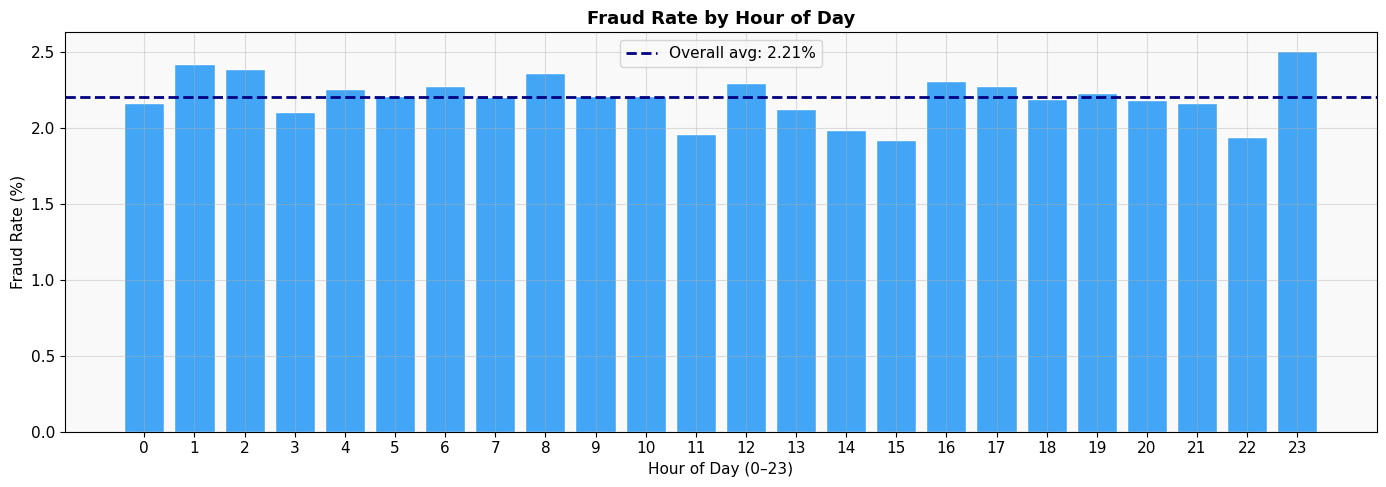

In [19]:
# Now we visualize fraud rate by hour of day
fraud_by_hour = df_processed.groupby('transaction_hour')['is_fraud'].mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))

# Here we've drawn a bar chart for fraud rate at each hour
overall = df['is_fraud'].mean() * 100
bar_colors = ['#EF5350' if v > overall * 1.3 else '#42A5F5'
              for v in fraud_by_hour.values]

bars = ax.bar(fraud_by_hour.index, fraud_by_hour.values,
               color=bar_colors, edgecolor='white')
ax.axhline(overall, color='navy', linestyle='--', linewidth=2,
           label=f'Overall avg: {overall:.2f}%')
ax.set_title('Fraud Rate by Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticks(range(24))
ax.legend()

plt.tight_layout()
plt.savefig('plot_09_fraud_by_hour.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- **X-axis** = দিনের ঘণ্টা (0 = মধ্যরাত, 12 = দুপুর)
- **Y-axis** = সেই ঘণ্টায় fraud rate (%)
- **নীল dashed line** = সার্বিক গড় fraud rate
- **লাল bar** = গড়ের ১.৩x বেশি fraud হওয়া ঘণ্টা (suspicious hours)

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

- কিছু নির্দিষ্ট ঘণ্টায় fraud rate গড়ের চেয়ে বেশি
- এই pattern-টি ML model-কে time-based fraud signal দিতে পারে
- রাতে বা ভোরে transaction হলে সেটি আরও সতর্কতার সাথে দেখা উচিত

---
## Step 14 — Preprocessing

In [20]:
# Now we apply all preprocessing steps to prepare the dataset for ML
from sklearn.preprocessing import RobustScaler, LabelEncoder

df_ml = df_processed.copy()

# Step A: Drop columns that are not useful for ML
# Here we've removed IDs, raw timestamp, and raw country text columns
drop_cols = ['transaction_id', 'user_id', 'transaction_time',
             'country', 'bin_country']
df_ml = df_ml.drop(columns=drop_cols)
print(f"Step A — Dropped {len(drop_cols)} columns: {drop_cols}")

# Step B: Encode categorical columns with LabelEncoder
# Here we've converted text columns to integers
label_encode_cols = ['channel', 'merchant_category']
le = LabelEncoder()
for col in label_encode_cols:
    df_ml[col] = le.fit_transform(df_ml[col])
    print(f"Step B — Label encoded '{col}'")

# Step C: Scale numeric features using RobustScaler
# Here we've used RobustScaler because our data has outliers
# RobustScaler uses median and IQR — not affected by extreme values
scale_cols = ['account_age_days', 'total_transactions_user', 'avg_amount_user',
              'amount', 'shipping_distance_km', 'amount_vs_avg']

scaler = RobustScaler()
df_ml[scale_cols] = scaler.fit_transform(df_ml[scale_cols])
print(f"Step C — RobustScaler applied to {len(scale_cols)} columns")

print()
print(f"Final DataFrame shape: {df_ml.shape[0]:,} rows × {df_ml.shape[1]} columns")

Step A — Dropped 5 columns: ['transaction_id', 'user_id', 'transaction_time', 'country', 'bin_country']
Step B — Label encoded 'channel'
Step B — Label encoded 'merchant_category'
Step C — RobustScaler applied to 6 columns

Final DataFrame shape: 299,695 rows × 16 columns


**Preprocessing-এর তিনটি ধাপ:**

**Step A — Drop করা:**
- `transaction_id`, `user_id` → unique identifier, কোনো pattern নেই
- `transaction_time` → raw string, আমরা `transaction_hour` বানিয়েছি
- `country`, `bin_country` → আমরা `country_match` বানিয়েছি

**Step B — Label Encoding:**
- `channel`: web=1, app=0 (বা যেভাবে LabelEncoder assign করে)
- `merchant_category`: travel, fashion... → 0, 1, 2, 3, 4
- ML model সংখ্যা বোঝে, text নয়

**Step C — RobustScaler:**
- `amount` max = $16,994, কিন্তু median = $90 → MinMaxScaler distort হবে
- RobustScaler Median ও IQR ব্যবহার করে — outlier-এর প্রভাব কম পড়ে
- তাই outlier-যুক্ত dataset-এ **RobustScaler সবচেয়ে নিরাপদ**

In [21]:
# Now we print the final preprocessed DataFrame
print("Final Preprocessed DataFrame — Column List:")
print("-" * 55)
for col in df_ml.columns:
    print(f"  {col:<28} {str(df_ml[col].dtype):<12}")

print()
print("First 5 rows of the final DataFrame:")
print()
df_ml.head()

Final Preprocessed DataFrame — Column List:
-------------------------------------------------------
  account_age_days             float64     
  total_transactions_user      float64     
  avg_amount_user              float64     
  amount                       float64     
  channel                      int64       
  merchant_category            int64       
  promo_used                   int64       
  avs_match                    int64       
  cvv_result                   int64       
  three_ds_flag                int64       
  shipping_distance_km         float64     
  is_fraud                     int64       
  country_match                int64       
  amount_vs_avg                float64     
  transaction_hour             int32       
  security_score               int64       

First 5 rows of the final DataFrame:



,account_age_days,total_transactions_user,avg_amount_user,amount,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,country_match,amount_vs_avg,transaction_hour,security_score
0,-0.917492,-0.4,0.454188,-0.035165,1,4,0,1,1,1,0.359271,0,1,-0.606589,4,3
1,-0.917492,-0.4,0.454188,0.120193,1,4,0,0,0,0,-0.452711,0,1,-0.379063,20,0
2,-0.917492,-0.4,0.454188,0.015905,0,4,1,1,1,1,-0.399662,0,1,-0.531772,6,3
3,-0.917492,-0.4,0.454188,0.150862,1,1,0,1,1,1,0.456306,0,1,-0.334114,17,3
4,-0.917492,-0.4,0.454188,0.288034,1,0,0,1,1,1,2.429599,0,0,-0.133236,1,3


In [22]:
# Here we've shown the final stats for the preprocessed DataFrame
print("Final DataFrame — Descriptive Statistics:")
print()
df_ml.describe().T.round(3)

Final DataFrame — Descriptive Statistics:



,count,mean,std,min,25%,50%,75%,max
account_age_days,299695.0,-0.002,0.578,-1.072,-0.505,0.0,0.495,1.007
total_transactions_user,299695.0,-0.033,0.598,-1.100,-0.500,0.0,0.500,0.900
avg_amount_user,299695.0,0.456,1.574,-0.681,-0.345,0.0,0.655,35.165
amount,299695.0,0.585,2.060,-0.597,-0.321,0.0,0.679,113.447
channel,299695.0,0.508,0.500,0.000,0.000,1.0,1.000,1.000
merchant_category,299695.0,1.998,1.415,0.000,1.000,2.0,3.000,4.000
promo_used,299695.0,0.154,0.361,0.000,0.000,0.0,0.000,1.000
avs_match,299695.0,0.838,0.368,0.000,1.000,1.0,1.000,1.000
cvv_result,299695.0,0.872,0.334,0.000,1.000,1.0,1.000,1.000
three_ds_flag,299695.0,0.785,0.411,0.000,1.000,1.0,1.000,1.000


**Final preprocessed DataFrame-এ কী আছে:**

- Scaled numeric columns-এ এখন mean ≈ 0 এবং range সংকুচিত — ML model সহজে শিখতে পারবে
- Categorical columns এখন integer
- নতুন engineered features যোগ হয়েছে
- Target column `is_fraud` অপরিবর্তিত (0/1)
- **কোনো missing value নেই**, **কোনো text column নেই** → ML-এর জন্য ready!

---
## Step 15 — Key Insights & Next Steps

In [23]:
# Now we print the complete EDA summary
total        = len(df)
fraud_total  = df['is_fraud'].sum()
fraud_rate   = fraud_total / total * 100

print("=" * 68)
print("      EDA FINAL SUMMARY — E-COMMERCE FRAUD DETECTION")
print("=" * 68)
print(f"""
DATASET FACTS:
  Total Transactions : {total:,}
  Fraud Cases        : {fraud_total:,}  ({fraud_rate:.2f}%)
  Missing Values     : 0  (clean dataset)
  Imbalance Ratio    : ~44:1

TOP FRAUD SIGNALS (ranked):
  1. cvv_result = 0     → Fraud rate 10.6%  (vs 1.0% when CVV correct)
  2. avs_match  = 0     → Fraud rate 9.7%   (vs 0.8% when address matches)
  3. three_ds_flag = 0  → Fraud rate 6.8%   (vs 1.0% with 3DS)
  4. shipping_distance  → Outlier zone fraud rate >> average
  5. amount             → Outlier zone fraud rate >> average
  6. channel = web      → Fraud 3.6%  (vs 0.8% for app)
  7. account_age_days   → Newer accounts = more fraud
  8. country_match = 0  → Card country ≠ transaction country = suspicious

WEAK FEATURES:
  • total_transactions_user  (corr ≈ -0.02)
  • avg_amount_user          (corr ≈ -0.001)
  • merchant_category        (all categories ~2.1–2.3% fraud)

ENGINEERED FEATURES ADDED:
  • country_match      — transaction country = card country?
  • amount_vs_avg      — how unusual is this transaction for this user?
  • transaction_hour   — time of day signal
  • security_score     — sum of 3 security checks (0–3)

PREPROCESSING APPLIED:
  ✅ Dropped IDs, raw timestamp, raw country columns
  ✅ Label encoded: channel, merchant_category
  ✅ RobustScaler: amount, distance, age, avg_amount, amount_vs_avg

NEXT STEPS (for ML model):
  [1]  Train/Test split with stratify=True (preserve 2.2% fraud ratio)
  [2]  Handle class imbalance → SMOTE or class_weight='balanced'
  [3]  Try models: Logistic Regression, Random Forest, XGBoost
  [4]  Evaluate with: Precision, Recall, F1, AUC-ROC (NOT just accuracy)
  [5]  Feature importance plot after model training
""")
print("=" * 68)

      EDA FINAL SUMMARY — E-COMMERCE FRAUD DETECTION

DATASET FACTS:
  Total Transactions : 299,695
  Fraud Cases        : 6,612  (2.21%)
  Missing Values     : 0  (clean dataset)
  Imbalance Ratio    : ~44:1

TOP FRAUD SIGNALS (ranked):
  1. cvv_result = 0     → Fraud rate 10.6%  (vs 1.0% when CVV correct)
  2. avs_match  = 0     → Fraud rate 9.7%   (vs 0.8% when address matches)
  3. three_ds_flag = 0  → Fraud rate 6.8%   (vs 1.0% with 3DS)
  4. shipping_distance  → Outlier zone fraud rate >> average
  5. amount             → Outlier zone fraud rate >> average
  6. channel = web      → Fraud 3.6%  (vs 0.8% for app)
  7. account_age_days   → Newer accounts = more fraud
  8. country_match = 0  → Card country ≠ transaction country = suspicious

WEAK FEATURES:
  • total_transactions_user  (corr ≈ -0.02)
  • avg_amount_user          (corr ≈ -0.001)
  • merchant_category        (all categories ~2.1–2.3% fraud)

ENGINEERED FEATURES ADDED:
  • country_match      — transaction country = card 

### 🏆 সবচেয়ে গুরুত্বপূর্ণ Learnings:

| যা শিখলাম | বিস্তারিত |
|---|---|
| **CVV ও AVS সবচেয়ে শক্তিশালী** | এগুলো fail হলে fraud rate ১০x বেশি — bank-এর সবচেয়ে গুরুত্বপূর্ণ check |
| **Web channel বেশি risky** | App-এর তুলনায় web-এ 4x বেশি fraud — app-এ বেশি authentication থাকে |
| **বড় amount ও দূরের shipping** = fraud signal | IQR outlier zone-এ fraud rate অনেক বেশি |
| **Class imbalance মারাত্মক** | 44:1 ratio — accuracy metric ব্যবহারযোগ্য নয়, Recall ও AUC দেখতে হবে |
| **Feature Engineering গুরুত্বপূর্ণ** | `country_match`, `security_score` নতুন করে বানানো features অনেক বেশি informative |

---

> ⚠️ **Interview tip:**  
> Fraud detection-এ **False Negative** (fraud miss করা) অনেক বেশি ক্ষতিকর।  
> তাই model evaluate করার সময় **Recall** ও **AUC-ROC** সবচেয়ে গুরুত্বপূর্ণ metric।  
> Accuracy দেখলে 97.8% পাওয়া যাবে — কিন্তু সেটা মূল্যহীন কারণ model সব fraud miss করতে পারে।

---